# Generative Adversarial Networks
### What they are, why the training loop is unusual, and how the maths works

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import rcParams

# ── Dark theme ────────────────────────────────────────────────────────────────
BG      = '#0d1117'
SURFACE = '#161b22'
ACCENT  = '#e05c5c'
TEXT    = '#c9d1d9'
MUTED   = '#484f58'
BLUE    = '#58a6ff'
GREEN   = '#3fb950'

rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    SURFACE,
    'axes.edgecolor':    MUTED,
    'axes.labelcolor':   TEXT,
    'xtick.color':       TEXT,
    'ytick.color':       TEXT,
    'text.color':        TEXT,
    'grid.color':        MUTED,
    'grid.alpha':        0.3,
    'legend.facecolor':  SURFACE,
    'legend.edgecolor':  MUTED,
    'figure.dpi':        110,
})

np.random.seed(42)
print("Ready.")

Ready.


## Part 1 — The problem GANs solve

I want to generate new data that looks like it came from some distribution I only have samples from.

Say I have 10,000 photos of faces. I want to generate new faces that could plausibly have been in that dataset — not copies, genuinely new ones. The core problem is: **I don't have an equation for the distribution of faces**. I just have samples.

The naive approach — fitting a model to the data and sampling from it — runs into the dimensionality problem immediately. A 256×256 RGB image is 196,608 numbers. Modelling that joint distribution explicitly is completely intractable.

### Goodfellow's insight (2014)

Don't model the distribution explicitly. Instead, train two networks in competition:

- A **Generator** that tries to produce fake data indistinguishable from real data
- A **Discriminator** that tries to tell real data from fake

They play a game against each other. The generator gets better at fooling the discriminator. The discriminator gets better at catching the generator. They push each other toward an equilibrium where the generator produces data so good the discriminator can't tell the difference.

That competitive dynamic is the whole idea. Everything else is implementation.

## Part 2 — The minimax objective

The formal version of that game is:

$$\min_G \max_D \; V(D, G) = \mathbb{E}_{x \sim p_{data}}[\log D(x)] + \mathbb{E}_{z \sim p_z}[\log(1 - D(G(z)))]$$

Let me unpack every piece:

| Symbol | What it is |
|--------|------------|
| $D(x)$ | Discriminator's probability that $x$ is real (output between 0 and 1) |
| $G(z)$ | Generator's output — a fake sample produced from noise $z$ |
| $z \sim p_z$ | Random noise vector sampled from a simple distribution (usually Gaussian) |
| $x \sim p_{data}$ | A real sample from the training data |
| $\mathbb{E}[\log D(x)]$ | How well D recognises real data — D wants this **high** |
| $\mathbb{E}[\log(1 - D(G(z)))]$ | How well D spots fakes — D wants this **high**, G wants this **low** |

**The discriminator** does gradient *ascent* — maximising $V$. It wants $D(x) \to 1$ for real data and $D(G(z)) \to 0$ for fakes.

**The generator** does gradient *descent* — minimising $V$. It wants $D(G(z)) \to 1$, meaning the discriminator thinks its fakes are real.

In practice: both networks do gradient descent on their own loss functions (one maximises, one minimises), alternating each batch.

## Part 3 — A 1D worked example

Before building full networks, I want to see the dynamics with something I can visualise completely.

**Real data distribution**: a Gaussian mixture — two humps. The generator doesn't know this; it only learns from the discriminator's feedback.

**Generator**: takes a single uniform random number and maps it to a sample. Starts by producing garbage; should learn to match the real distribution.

**Discriminator**: takes a single number and outputs a probability of it being real.

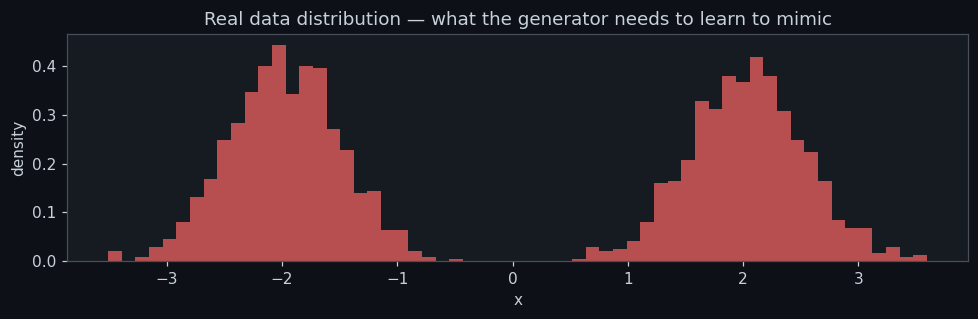

In [2]:
# ── Real data: mixture of two Gaussians ───────────────────────────────────────
def sample_real(n):
    """Sample from a bimodal distribution: two Gaussians at -2 and +2."""
    which = np.random.randint(0, 2, n)
    means = np.array([-2.0, 2.0])[which]
    return np.random.normal(means, 0.5)

# See what we're working with
real_samples = sample_real(2000)

fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(real_samples, bins=60, color=ACCENT, alpha=0.8, density=True)
ax.set_title('Real data distribution — what the generator needs to learn to mimic', color=TEXT)
ax.set_xlabel('x')
ax.set_ylabel('density')
plt.tight_layout()
plt.show()

In [3]:
# ── Tiny neural networks in pure numpy ────────────────────────────────────────
# Each network is just one hidden layer: input → hidden (tanh) → output (sigmoid)
# I'm keeping them small so the training dynamics are visible

def sigmoid(x):     return 1 / (1 + np.exp(-np.clip(x, -50, 50)))
def tanh(x):        return np.tanh(x)
def tanh_grad(x):   return 1 - np.tanh(x)**2

def init_network(in_dim, hidden_dim, out_dim, scale=0.3):
    """Xavier-ish initialisation."""
    return {
        'W1': np.random.randn(in_dim,     hidden_dim) * scale,
        'b1': np.zeros(hidden_dim),
        'W2': np.random.randn(hidden_dim, out_dim)    * scale,
        'b2': np.zeros(out_dim),
    }

def forward_D(params, x):
    """Discriminator forward pass. x: (batch,1) → prob: (batch,1)"""
    h  = tanh(x   @ params['W1'] + params['b1'])
    out = sigmoid(h @ params['W2'] + params['b2'])
    return out, h

def forward_G(params, z):
    """Generator forward pass. z: (batch,1) → x_fake: (batch,1)"""
    h   = tanh(z   @ params['W1'] + params['b1'])
    out = h @ params['W2'] + params['b2']   # no activation — output is unbounded
    return out, h

# Initialise both networks
D_params = init_network(1, 16, 1)
G_params = init_network(1, 16, 1)

print("Discriminator parameters:", sum(v.size for v in D_params.values()))
print("Generator parameters:    ", sum(v.size for v in G_params.values()))

Discriminator parameters: 49
Generator parameters:     49


## Part 4 — The training loop

Each iteration has two phases:

**Phase 1 — Train the discriminator**  
Show it real samples (label = 1) and fake samples (label = 0).  
Loss: binary cross-entropy. Update D's weights only.

$$\mathcal{L}_D = -\frac{1}{m}\sum \left[\log D(x_{real}) + \log(1 - D(G(z)))\right]$$

**Phase 2 — Train the generator**  
Generate fakes, pass through the (now updated) discriminator.  
Loss: how badly the discriminator spotted them as fake.  
Update G's weights only — D's weights are frozen during this phase.

$$\mathcal{L}_G = -\frac{1}{m}\sum \log D(G(z))$$

Note: this is the **non-saturating** generator loss (Goodfellow's practical recommendation). The theoretical objective has G minimise $\log(1 - D(G(z)))$, but early in training when D easily spots fakes, that term saturates near 0 and gradients vanish. Maximising $\log D(G(z))$ instead gives the same equilibrium but much healthier gradients.

In [4]:
def train_step(D_params, G_params, lr=0.001, batch_size=128):
    """
    One full GAN training iteration.
    Returns updated params and losses for logging.
    """
    eps = 1e-8  # prevent log(0)

    # ── Sample data ───────────────────────────────────────────────────────────
    x_real = sample_real(batch_size).reshape(-1, 1)
    z      = np.random.uniform(-1, 1, (batch_size, 1))  # noise input to G

    x_fake, h_G = forward_G(G_params, z)

    # ── Phase 1: Train Discriminator ──────────────────────────────────────────
    d_real, h_D_real = forward_D(D_params, x_real)
    d_fake, h_D_fake = forward_D(D_params, x_fake)

    # Binary cross-entropy loss
    loss_D = -np.mean(np.log(d_real + eps) + np.log(1 - d_fake + eps))

    # Gradients for D (real samples: target=1, fake samples: target=0)
    dL_d_real = -(1 / (d_real + eps)) / batch_size
    dL_d_fake =  (1 / (1 - d_fake + eps)) / batch_size

    # Backprop through D for real samples
    dout_real = dL_d_real * d_real * (1 - d_real)          # sigmoid grad
    dW2_real  = h_D_real.T @ dout_real
    db2_real  = dout_real.sum(axis=0)
    dh_real   = dout_real @ D_params['W2'].T * tanh_grad(x_real @ D_params['W1'] + D_params['b1'])
    dW1_real  = x_real.T @ dh_real
    db1_real  = dh_real.sum(axis=0)

    # Backprop through D for fake samples
    dout_fake = dL_d_fake * d_fake * (1 - d_fake)
    dW2_fake  = h_D_fake.T @ dout_fake
    db2_fake  = dout_fake.sum(axis=0)
    dh_fake   = dout_fake @ D_params['W2'].T * tanh_grad(x_fake @ D_params['W1'] + D_params['b1'])
    dW1_fake  = x_fake.T @ dh_fake
    db1_fake  = dh_fake.sum(axis=0)

    # Update D
    D_params['W2'] -= lr * (dW2_real + dW2_fake)
    D_params['b2'] -= lr * (db2_real + db2_fake)
    D_params['W1'] -= lr * (dW1_real + dW1_fake)
    D_params['b1'] -= lr * (db1_real + db1_fake)

    # ── Phase 2: Train Generator ──────────────────────────────────────────────
    # Fresh forward pass with updated D
    x_fake2, h_G2 = forward_G(G_params, z)
    d_fake2, h_D2 = forward_D(D_params, x_fake2)

    # Non-saturating loss: maximise log D(G(z))
    loss_G = -np.mean(np.log(d_fake2 + eps))

    # Gradient of loss_G w.r.t. D's output
    dL_dG = -(1 / (d_fake2 + eps)) / batch_size

    # Backprop through D (frozen) then through G
    dout2    = dL_dG * d_fake2 * (1 - d_fake2)
    dx_fake2 = dout2 @ D_params['W2'].T * tanh_grad(x_fake2 @ D_params['W1'] + D_params['b1'])
    dx_fake2 = dx_fake2 @ D_params['W1'].T   # gradient w.r.t. G's output

    # Backprop through G
    dW2_G = h_G2.T @ dx_fake2
    db2_G = dx_fake2.sum(axis=0)
    dh_G2 = dx_fake2 @ G_params['W2'].T * tanh_grad(z @ G_params['W1'] + G_params['b1'])
    dW1_G = z.T @ dh_G2
    db1_G = dh_G2.sum(axis=0)

    # Update G
    G_params['W2'] -= lr * dW2_G
    G_params['b2'] -= lr * db2_G
    G_params['W1'] -= lr * dW1_G
    G_params['b1'] -= lr * db1_G

    return D_params, G_params, float(loss_D), float(loss_G)

print("Training step defined.")

Training step defined.


In [5]:
# ── Train ──────────────────────────────────────────────────────────────────────
# Reinitialise cleanly
np.random.seed(0)
D_params = init_network(1, 16, 1)
G_params = init_network(1, 16, 1)

n_steps   = 3000
log_every = 300
snapshots = []   # (step, fake samples) for visualisation
d_losses, g_losses = [], []

for step in range(n_steps):
    D_params, G_params, ld, lg = train_step(D_params, G_params, lr=0.003)
    d_losses.append(ld)
    g_losses.append(lg)

    if step % log_every == 0 or step == n_steps - 1:
        z_test   = np.random.uniform(-1, 1, (2000, 1))
        fakes, _ = forward_G(G_params, z_test)
        snapshots.append((step, fakes.flatten().copy()))
        print(f"Step {step:4d} | D loss: {ld:.3f} | G loss: {lg:.3f}")

Step    0 | D loss: 1.391 | G loss: 0.694
Step  300 | D loss: 1.325 | G loss: 0.790
Step  600 | D loss: 1.250 | G loss: 0.857
Step  900 | D loss: 1.181 | G loss: 0.929
Step 1200 | D loss: 1.060 | G loss: 1.017
Step 1500 | D loss: 0.971 | G loss: 1.109
Step 1800 | D loss: 0.954 | G loss: 1.113
Step 2100 | D loss: 1.063 | G loss: 1.149
Step 2400 | D loss: 1.082 | G loss: 1.181
Step 2700 | D loss: 1.023 | G loss: 1.158
Step 2999 | D loss: 1.042 | G loss: 1.115


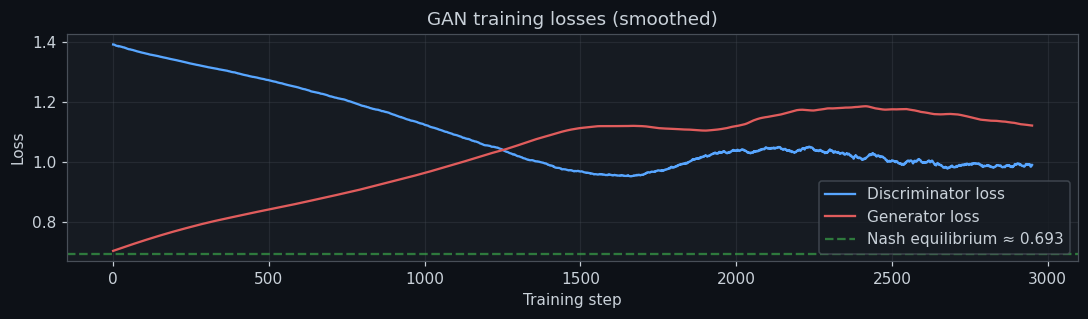


The dashed line marks log(2) ≈ 0.693.

At the theoretical Nash equilibrium, the generator perfectly matches the real
distribution. The discriminator can no longer tell real from fake — it outputs
0.5 for everything. At that point:

  D loss = -(log(0.5) + log(0.5)) = 2 × log(2) ≈ 1.386  ... per sample
  averaged over the batch             → log(2) ≈ 0.693

Both losses converging toward that line is a sign of healthy training.



In [6]:
# ── Loss curves ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 3))

window = 50
d_smooth = np.convolve(d_losses, np.ones(window)/window, mode='valid')
g_smooth = np.convolve(g_losses, np.ones(window)/window, mode='valid')

ax.plot(d_smooth, color=BLUE,   label='Discriminator loss', linewidth=1.5)
ax.plot(g_smooth, color=ACCENT, label='Generator loss',     linewidth=1.5)
ax.axhline(np.log(2), color=GREEN, linestyle='--', alpha=0.6, label=f'Nash equilibrium ≈ {np.log(2):.3f}')
ax.set_title('GAN training losses (smoothed)', color=TEXT)
ax.set_xlabel('Training step')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

print(f"""
The dashed line marks log(2) ≈ {np.log(2):.3f}.

At the theoretical Nash equilibrium, the generator perfectly matches the real
distribution. The discriminator can no longer tell real from fake — it outputs
0.5 for everything. At that point:

  D loss = -(log(0.5) + log(0.5)) = 2 × log(2) ≈ 1.386  ... per sample
  averaged over the batch             → log(2) ≈ 0.693

Both losses converging toward that line is a sign of healthy training.
""")

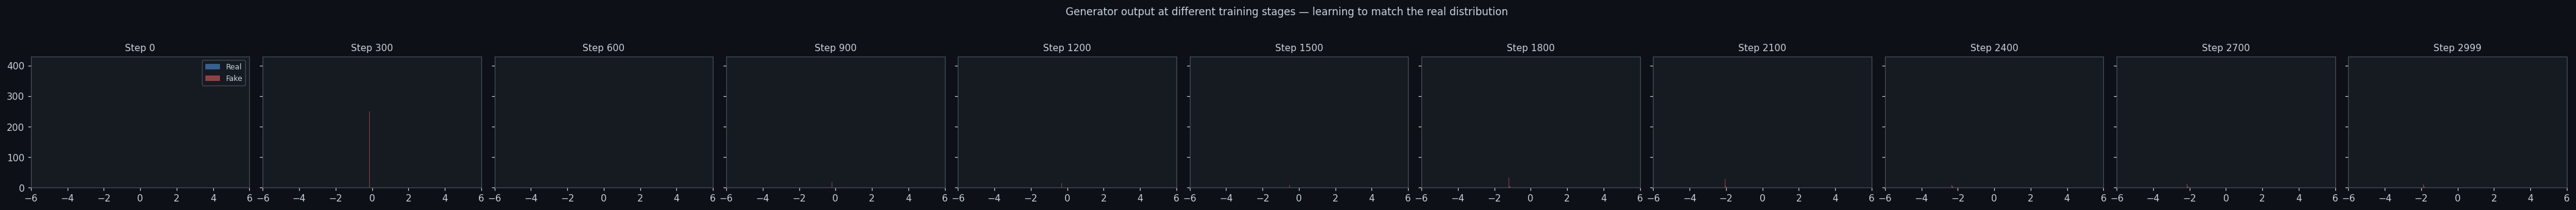

In [7]:
# ── Generator evolution across training ────────────────────────────────────────
n_snap = len(snapshots)
fig, axes = plt.subplots(1, n_snap, figsize=(3.5 * n_snap, 3), sharey=True)

x_range = np.linspace(-5, 5, 300).reshape(-1, 1)

for ax, (step, fakes) in zip(axes, snapshots):
    real_plot = sample_real(2000)
    ax.hist(real_plot, bins=50, color=BLUE,   alpha=0.5, density=True, label='Real')
    ax.hist(fakes,     bins=50, color=ACCENT, alpha=0.6, density=True, label='Fake')
    ax.set_title(f'Step {step}', color=TEXT, fontsize=10)
    ax.set_xlim(-6, 6)
    if step == 0:
        ax.legend(fontsize=8)

fig.suptitle('Generator output at different training stages — learning to match the real distribution',
             color=TEXT, fontsize=11, y=1.03)
plt.tight_layout()
plt.show()

## Part 5 — What the discriminator has learned

The discriminator's output is a probability surface over the input space. At the start, it has no idea what's real. By the end, it should assign high probability to the regions where real data lives — but only until the generator catches up.

At Nash equilibrium, $D(x) = 0.5$ everywhere — it's no better than a coin flip because the fake distribution is indistinguishable from the real one.

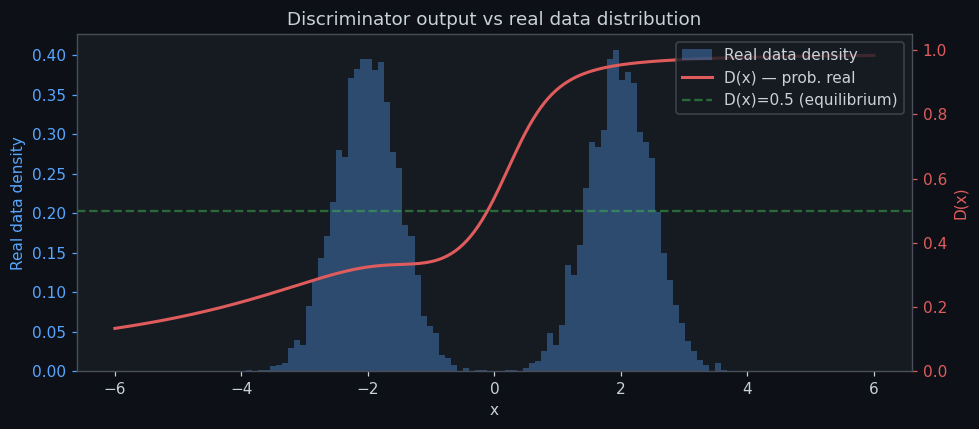

In [8]:
x_range = np.linspace(-6, 6, 400).reshape(-1, 1)
d_output, _ = forward_D(D_params, x_range)

fig, ax = plt.subplots(figsize=(9, 4))

# Real data density
real_samples_plot = sample_real(5000)
ax.hist(real_samples_plot, bins=80, color=BLUE, alpha=0.35, density=True, label='Real data density')

# Discriminator output
ax2 = ax.twinx()
ax2.plot(x_range, d_output, color=ACCENT, linewidth=2, label='D(x) — prob. real')
ax2.axhline(0.5, color=GREEN, linestyle='--', alpha=0.5, label='D(x)=0.5 (equilibrium)')
ax2.set_ylim(0, 1.05)
ax2.set_ylabel('D(x)', color=ACCENT)
ax2.tick_params(axis='y', colors=ACCENT)

ax.set_xlabel('x')
ax.set_ylabel('Real data density', color=BLUE)
ax.tick_params(axis='y', colors=BLUE)
ax.set_title('Discriminator output vs real data distribution', color=TEXT)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

## Part 6 — Why GAN training is hard

The loss curves look cleaner in notebooks than in real projects. GANs are notoriously unstable. Understanding the failure modes matters more than the happy path.

### Mode collapse

The generator discovers that producing *one type* of output consistently fools the discriminator, and stops exploring. In our 1D example: rather than learning both humps at -2 and +2, the generator might collapse onto just one hump. It's found a local strategy that works well enough and gets stuck.

The root cause: the generator's loss has no term that rewards *diversity*. It only rewards fooling the discriminator.

### The discriminator winning too hard

If the discriminator becomes much better than the generator early in training, it outputs values very close to 0 for all fakes. The generator's gradient becomes $\frac{d}{dG}[-\log D(G(z))]$ — when $D(G(z)) \approx 0$, this gradient is enormous, then $D$ updates and it becomes enormous in a different direction. Training becomes chaotic.

### Non-convergence

The minimax game doesn't have a guaranteed convergence path like ordinary SGD does with a fixed loss landscape. As G improves, the loss landscape D is optimising over changes — and vice versa. They can end up chasing each other in circles.

### What Wasserstein GANs (WGANs) fixed

The Wasserstein GAN (2017) replaced the binary cross-entropy objective with the *Earth Mover's Distance* — a metric that measures how much probability mass needs to move and how far, rather than comparing probability ratios. The result:
- Meaningful loss values that correlate with sample quality (the original GAN loss doesn't)
- Much more stable training
- The discriminator (called the *critic* in WGAN) no longer needs to be carefully balanced against the generator

Most production GAN work since 2017 uses WGAN or a variant of it.

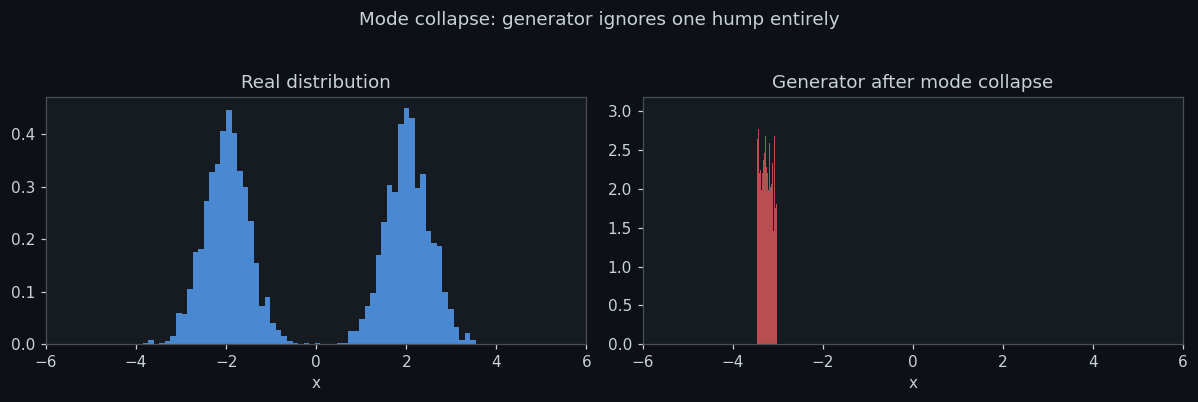

Generator output std: 0.131  (real data std ≈ 2.043)
Low std relative to real data is a hallmark of mode collapse.


In [9]:
# ── Demonstrate mode collapse ──────────────────────────────────────────────────
# Train with a very high learning rate and a strong discriminator advantage.
# The generator should collapse to producing one mode.

np.random.seed(1)
D_mc = init_network(1, 32, 1, scale=0.5)  # stronger D
G_mc = init_network(1, 8,  1, scale=0.1)  # weaker G

for step in range(2000):
    D_mc, G_mc, _, _ = train_step(D_mc, G_mc, lr=0.015)  # aggressive lr

z_test   = np.random.uniform(-1, 1, (3000, 1))
fakes_mc, _ = forward_G(G_mc, z_test)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

for ax, fakes, title, color in zip(
    axes,
    [sample_real(3000), fakes_mc.flatten()],
    ['Real distribution', 'Generator after mode collapse'],
    [BLUE, ACCENT]
):
    ax.hist(fakes, bins=60, color=color, alpha=0.8, density=True)
    ax.set_title(title, color=TEXT)
    ax.set_xlim(-6, 6)
    ax.set_xlabel('x')

fig.suptitle('Mode collapse: generator ignores one hump entirely', color=TEXT, y=1.03)
plt.tight_layout()
plt.show()

print(f"Generator output std: {fakes_mc.std():.3f}  (real data std ≈ {sample_real(3000).std():.3f})")
print("Low std relative to real data is a hallmark of mode collapse.")

## Part 7 — From 1D to images: what changes

The math stays identical. What changes is architecture:

**Generator** for images:
- Input: a latent vector $z$ (e.g. 100 random numbers)
- Uses **transposed convolutions** to upsample from a tiny spatial grid to full image resolution
- $z \in \mathbb{R}^{100}$ → reshape to $(4 \times 4 \times 512)$ → upsample → upsample → upsample → $(64 \times 64 \times 3)$

**Discriminator** for images:
- Input: an image (real or fake)
- Uses standard convolutions to downsample
- Output: single probability

**DCGAN** (Deep Convolutional GAN, 2015) was the first architecture that made this reliably work. Key stabilisation tricks: batch normalisation in both networks, LeakyReLU in the discriminator, no pooling layers.

**StyleGAN** (2019, NVIDIA) extended this with a mapping network that transforms $z$ into an intermediate latent space $w$, which then controls the generator at multiple scales. That's what produces the hyperrealistic face generation you've probably seen.

The adversarial training loop — alternating D and G updates, same minimax objective — is identical throughout.

## Summary

| Concept | What it is |
|---------|------------|
| **Generator** | Maps random noise $z$ to fake samples; never sees real data directly |
| **Discriminator** | Binary classifier: real vs fake; its feedback is the only signal G gets |
| **Minimax objective** | D maximises, G minimises the same value function — they pull in opposite directions |
| **Non-saturating loss** | Practical fix: G maximises $\log D(G(z))$ instead of minimising $\log(1-D(G(z)))$ |
| **Nash equilibrium** | G perfectly matches real distribution; D outputs 0.5 everywhere; both losses → log(2) |
| **Mode collapse** | G finds one output that reliably fools D and gets stuck there; diversity collapses |
| **WGAN** | Replaces BCE with Earth Mover's Distance; more stable; loss correlates with quality |

---

### The one equation that matters

$$\boxed{\min_G \max_D \; \mathbb{E}_{x \sim p_{data}}[\log D(x)] + \mathbb{E}_{z \sim p_z}[\log(1 - D(G(z)))]}$$

---

## Things to try

- Change `sample_real` to a single Gaussian — does training converge faster?
- Try a three-hump distribution — does the generator find all three modes?
- Remove the learning rate difference between D and G — does mode collapse become more or less likely?
- Increase hidden layer size in G but not D — what happens to the loss curves?